# Test 02: Phase Transition, Finding the Edge of Chaos

## Goal

Reaction-diffusion systems like FluidWorld have three dynamical regimes:

| Regime | Behavior | Consequence |
|--------|----------|-------------|
| **Sub-critical** | Energy decays exponentially | Latent field dies, no useful representation |
| **Critical** (*edge of chaos*) | Energy fluctuates around a stable attractor | Sweet spot: expressive without blowing up |
| **Super-critical** | Energy diverges (NaN) | PDE explodes, training impossible |

## Hypothesis

The critical regime occupies a narrow band in (D, dt) space. A well-trained model should have learned D and dt values that fall in this band.

## Protocol

1. Sweep `diffusion_scale` (0.01 to 0.5) and `dt` (0.01 to 0.3) systematically
2. For each (D, dt) pair: init a random field, run N PDE steps
3. Measure: energy trajectory, Lyapunov exponent, E_final/E_initial ratio
4. Build a phase diagram (heatmap)
5. Locate the model's learned values on this diagram

## Connection to LeCun's vision

LeCun's JEPA theory says a world model must operate at the edge of chaos: dynamic enough to predict transitions, stable enough not to diverge. This test checks that empirically.

In [1]:
import sys
import os

# Ajouter le repertoire racine FluidWorld au path
FLUIDWORLD_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if FLUIDWORLD_ROOT not in sys.path:
    sys.path.insert(0, FLUIDWORLD_ROOT)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch

from fluidworld.core.diffusion import Laplacian2D
from fluidworld.core.fluid_layer import FluidLayer2D, ReactionMLP, RMSNorm

print(f"FluidWorld root: {FLUIDWORLD_ROOT}")
print(f"PyTorch: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

FluidWorld root: c:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld
PyTorch: 2.10.0+cu128
Device: cuda


## 1. Sweep configuration

In [2]:
# --- Parametres du balayage ---
CHANNELS = 32           # Nombre de canaux latents
SPATIAL_HW = 16         # Resolution spatiale du champ
N_PDE_STEPS = 100       # Nombre de pas PDE par experience
BATCH_SIZE = 4          # Taille du batch (pour moyenner le bruit)
EPSILON_LYAPUNOV = 1e-4 # Perturbation pour l'exposant de Lyapunov

# Grille de balayage
diffusion_scales = np.linspace(0.01, 0.5, 15)
dt_values = np.linspace(0.01, 0.3, 15)

print(f"Grille : {len(diffusion_scales)} x {len(dt_values)} = {len(diffusion_scales) * len(dt_values)} experiences")
print(f"diffusion_scale : {diffusion_scales[0]:.3f} -> {diffusion_scales[-1]:.3f}")
print(f"dt : {dt_values[0]:.3f} -> {dt_values[-1]:.3f}")

Grille : 15 x 15 = 225 experiences
diffusion_scale : 0.010 -> 0.500
dt : 0.010 -> 0.300


## 2. Pure PDE simulation

Isolating PDE dynamics (diffusion + reaction) without the extra mechanisms (DeltaNet, Titans, Hebbian) to study the base system behavior.

In [3]:
@torch.no_grad()
def run_pde_simulation(diffusion_scale: float, dt: float,
                        n_steps: int = N_PDE_STEPS,
                        channels: int = CHANNELS,
                        spatial_hw: int = SPATIAL_HW,
                        batch_size: int = BATCH_SIZE,
                        device: torch.device = device):
    """
    Simule le PDE avec diffusion_scale et dt donnes.
    
    Retourne:
        energies: liste de l'energie a chaque pas
        lyapunov: exposant de Lyapunov estime
        stable: True si pas de NaN
    """
    # Creer le Laplacien avec les parametres voulus
    lap = Laplacian2D(
        channels=channels,
        dilations=[1, 4],
        signed_diffusion=False,
        diffusion_scale=diffusion_scale,
    ).to(device)
    
    # Reaction MLP (poids aleatoires mais fixes pour la comparaison)
    torch.manual_seed(42)
    reaction = ReactionMLP(channels).to(device)
    norm = RMSNorm(channels).to(device)
    
    # Initialiser le champ aleatoire
    torch.manual_seed(123)
    u = torch.randn(batch_size, channels, spatial_hw, spatial_hw, device=device) * 0.1
    
    # Copie perturbee pour Lyapunov
    u_perturb = u + EPSILON_LYAPUNOV * torch.randn_like(u)
    
    energies = []
    divergences = []
    
    for step in range(n_steps):
        # Energie : sum(u^2) moyennee sur le batch
        energy = (u ** 2).sum(dim=(1, 2, 3)).mean().item()
        energies.append(energy)
        
        if np.isnan(energy) or np.isinf(energy) or energy > 1e10:
            # Remplir le reste avec NaN
            energies.extend([float('nan')] * (n_steps - step - 1))
            break
        
        # Divergence pour Lyapunov
        div = (u - u_perturb).pow(2).sum(dim=(1, 2, 3)).mean().sqrt().item()
        divergences.append(max(div, 1e-20))  # eviter log(0)
        
        # --- Pas PDE pour u ---
        diff = lap(u)
        b, c, h, w = u.shape
        u_flat = u.permute(0, 2, 3, 1).reshape(b, h * w, c)
        diff_flat = diff.permute(0, 2, 3, 1).reshape(b, h * w, c)
        react = reaction(u_flat)
        du = diff_flat + react
        u_flat = u_flat + dt * du
        if (step + 1) % 2 == 0:
            u_flat = norm(u_flat)
        u = u_flat.reshape(b, h, w, c).permute(0, 3, 1, 2).contiguous()
        
        # --- Meme pas PDE pour u_perturb ---
        diff_p = lap(u_perturb)
        up_flat = u_perturb.permute(0, 2, 3, 1).reshape(b, h * w, c)
        diff_p_flat = diff_p.permute(0, 2, 3, 1).reshape(b, h * w, c)
        react_p = reaction(up_flat)
        du_p = diff_p_flat + react_p
        up_flat = up_flat + dt * du_p
        if (step + 1) % 2 == 0:
            up_flat = norm(up_flat)
        u_perturb = up_flat.reshape(b, h, w, c).permute(0, 3, 1, 2).contiguous()
    
    # Exposant de Lyapunov : pente de log(divergence) vs temps
    if len(divergences) > 10:
        log_divs = np.log(np.array(divergences))
        valid = ~np.isnan(log_divs) & ~np.isinf(log_divs)
        if valid.sum() > 5:
            t = np.arange(len(log_divs))[valid]
            ld = log_divs[valid]
            # Regression lineaire pour la pente
            coeffs = np.polyfit(t, ld, 1)
            lyapunov = coeffs[0]
        else:
            lyapunov = float('nan')
    else:
        lyapunov = float('nan')
    
    return {
        "energies": energies,
        "lyapunov": lyapunov,
        "energy_ratio": energies[-1] / max(energies[0], 1e-10) if not np.isnan(energies[-1]) else float('inf'),
        "stable": not any(np.isnan(e) for e in energies),
    }

## 3. Running the parameter sweep

Launching simulation for each (diffusion_scale, dt) pair and collecting metrics.

In [4]:
# Matrices de resultats
energy_ratio_map = np.zeros((len(dt_values), len(diffusion_scales)))
lyapunov_map = np.zeros((len(dt_values), len(diffusion_scales)))
regime_map = np.zeros((len(dt_values), len(diffusion_scales)))  # 0=sub, 1=critical, 2=super

all_results = {}

total = len(dt_values) * len(diffusion_scales)
count = 0

for i, dt_val in enumerate(dt_values):
    for j, ds_val in enumerate(diffusion_scales):
        count += 1
        if count % 20 == 0:
            print(f"  Progression: {count}/{total} ({100*count/total:.0f}%)")
        
        result = run_pde_simulation(
            diffusion_scale=ds_val,
            dt=dt_val,
        )
        
        er = result["energy_ratio"]
        ly = result["lyapunov"]
        
        energy_ratio_map[i, j] = np.clip(er, 0, 100) if not np.isinf(er) else 100
        lyapunov_map[i, j] = ly if not np.isnan(ly) else 5.0
        
        # Classification du regime
        if not result["stable"] or er > 10:
            regime_map[i, j] = 2  # super-critique (explose)
        elif er < 0.1:
            regime_map[i, j] = 0  # sous-critique (meurt)
        else:
            regime_map[i, j] = 1  # critique (stable)
        
        all_results[(i, j)] = result

print(f"\nBalayage termine! {total} experiences completees.")

  Progression: 20/225 (9%)
  Progression: 40/225 (18%)
  Progression: 60/225 (27%)
  Progression: 80/225 (36%)
  Progression: 100/225 (44%)
  Progression: 120/225 (53%)
  Progression: 140/225 (62%)
  Progression: 160/225 (71%)
  Progression: 180/225 (80%)
  Progression: 200/225 (89%)
  Progression: 220/225 (98%)

Balayage termine! 225 experiences completees.


## 4. Phase diagram: the dynamical regime landscape

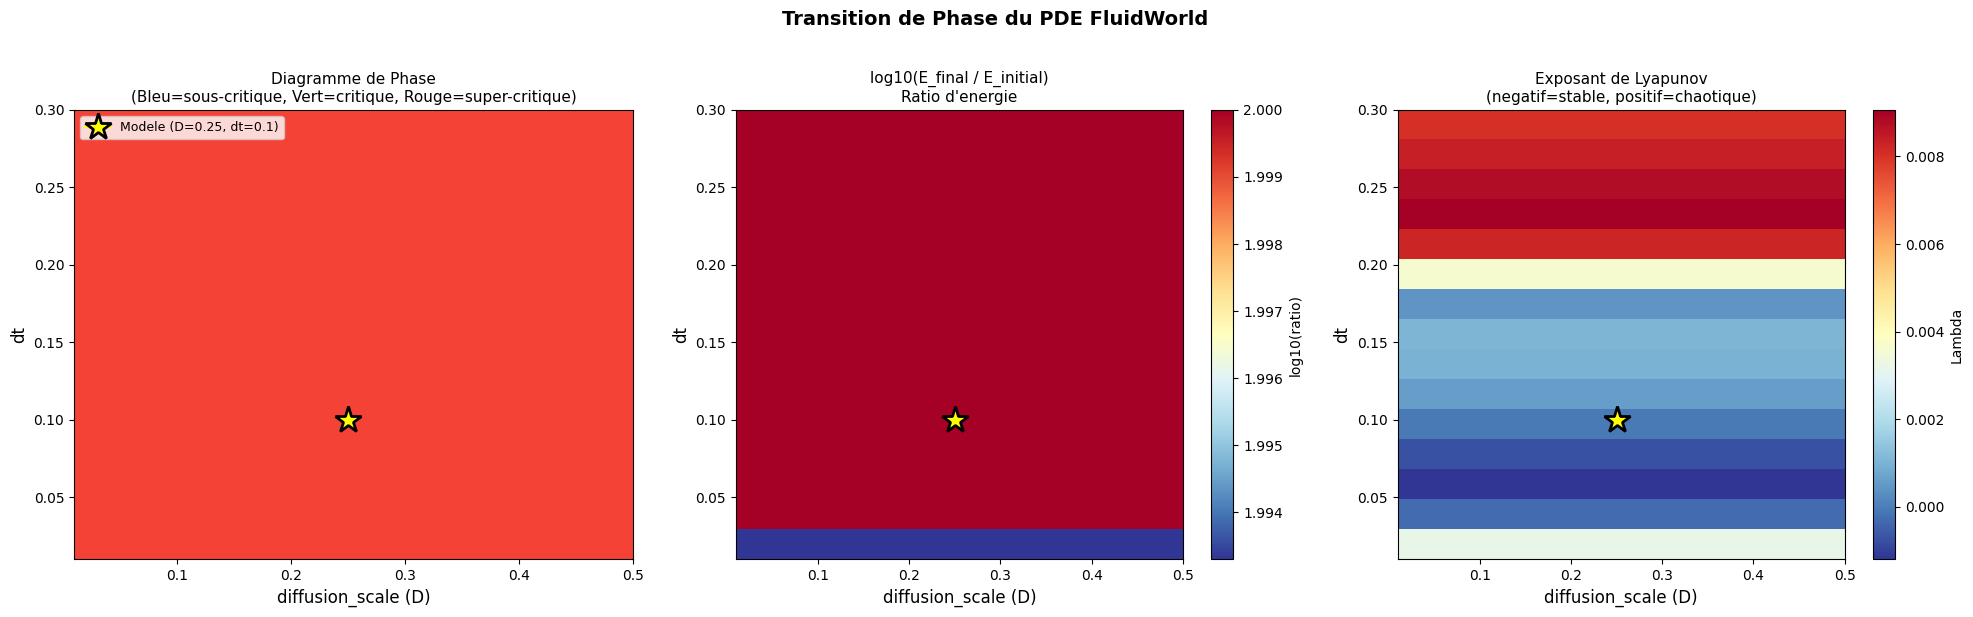

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 4a. Carte des regimes ---
ax = axes[0]
cmap_regime = mcolors.ListedColormap(['#2196F3', '#4CAF50', '#F44336'])  # bleu, vert, rouge
bounds = [-0.5, 0.5, 1.5, 2.5]
norm_regime = mcolors.BoundaryNorm(bounds, cmap_regime.N)

im0 = ax.imshow(regime_map, origin='lower', aspect='auto', cmap=cmap_regime, norm=norm_regime,
                extent=[diffusion_scales[0], diffusion_scales[-1], dt_values[0], dt_values[-1]])
ax.set_xlabel('diffusion_scale (D)', fontsize=12)
ax.set_ylabel('dt', fontsize=12)
ax.set_title('Diagramme de Phase\n(Bleu=sous-critique, Vert=critique, Rouge=super-critique)', fontsize=11)

# Marquer les valeurs par defaut du modele
# BeliefField: diffusion_scale=0.25, dt clamped in [0.01, 0.3], init log_dt=log(0.1)
model_D = 0.25
model_dt = 0.1
ax.plot(model_D, model_dt, marker='*', color='yellow', markersize=20, markeredgecolor='black',
        markeredgewidth=2, label=f'Modele (D={model_D}, dt={model_dt})')
ax.legend(loc='upper left', fontsize=9)

# --- 4b. Ratio d'energie ---
ax = axes[1]
im1 = ax.imshow(np.log10(np.clip(energy_ratio_map, 1e-3, 1e3)), origin='lower', aspect='auto',
                cmap='RdYlBu_r',
                extent=[diffusion_scales[0], diffusion_scales[-1], dt_values[0], dt_values[-1]])
ax.set_xlabel('diffusion_scale (D)', fontsize=12)
ax.set_ylabel('dt', fontsize=12)
ax.set_title('log10(E_final / E_initial)\nRatio d\'energie', fontsize=11)
plt.colorbar(im1, ax=ax, label='log10(ratio)')
ax.plot(model_D, model_dt, marker='*', color='yellow', markersize=20, markeredgecolor='black', markeredgewidth=2)

# --- 4c. Exposant de Lyapunov ---
ax = axes[2]
im2 = ax.imshow(np.clip(lyapunov_map, -2, 2), origin='lower', aspect='auto',
                cmap='RdYlBu_r',
                extent=[diffusion_scales[0], diffusion_scales[-1], dt_values[0], dt_values[-1]])
ax.set_xlabel('diffusion_scale (D)', fontsize=12)
ax.set_ylabel('dt', fontsize=12)
ax.set_title('Exposant de Lyapunov\n(negatif=stable, positif=chaotique)', fontsize=11)
plt.colorbar(im2, ax=ax, label='Lambda')
ax.plot(model_D, model_dt, marker='*', color='yellow', markersize=20, markeredgecolor='black', markeredgewidth=2)

plt.suptitle('Transition de Phase du PDE FluidWorld', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_dir = os.path.join('..', 'paper', 'figures')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'fig_phase_diagram.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(save_dir, 'fig_phase_diagram.png'), bbox_inches='tight', dpi=150)
plt.show()

## 5. Energy trajectories for representative regimes

One example from each regime to show the time evolution.

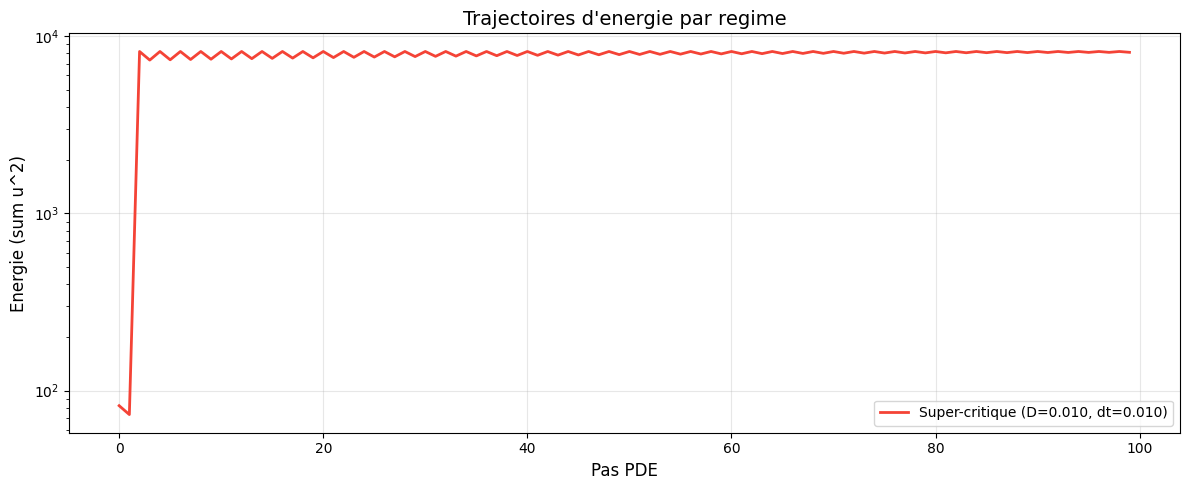

In [6]:
# Selectionner un exemple de chaque regime
examples = {}
for regime_id, regime_name, color in [(0, 'Sous-critique', '#2196F3'), 
                                       (1, 'Critique (edge of chaos)', '#4CAF50'),
                                       (2, 'Super-critique', '#F44336')]:
    for (i, j), result in all_results.items():
        if regime_map[i, j] == regime_id:
            examples[regime_name] = {
                'result': result,
                'D': diffusion_scales[j],
                'dt': dt_values[i],
                'color': color,
            }
            break

fig, ax = plt.subplots(figsize=(12, 5))

for name, data in examples.items():
    energies = data['result']['energies']
    # Ne tracer que les valeurs finies
    valid_energies = [e for e in energies if not np.isnan(e) and e < 1e8]
    label = f"{name} (D={data['D']:.3f}, dt={data['dt']:.3f})"
    ax.plot(valid_energies, color=data['color'], linewidth=2, label=label)

ax.set_xlabel('Pas PDE', fontsize=12)
ax.set_ylabel('Energie (sum u^2)', fontsize=12)
ax.set_title('Trajectoires d\'energie par regime', fontsize=14)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_dir = os.path.join('..', 'paper', 'figures')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'fig_energy_trajectories.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(save_dir, 'fig_energy_trajectories.png'), bbox_inches='tight', dpi=150)
plt.show()

## 6. Critical boundary contour

Iso-lines of the energy ratio to pinpoint the exact boundary between regimes.

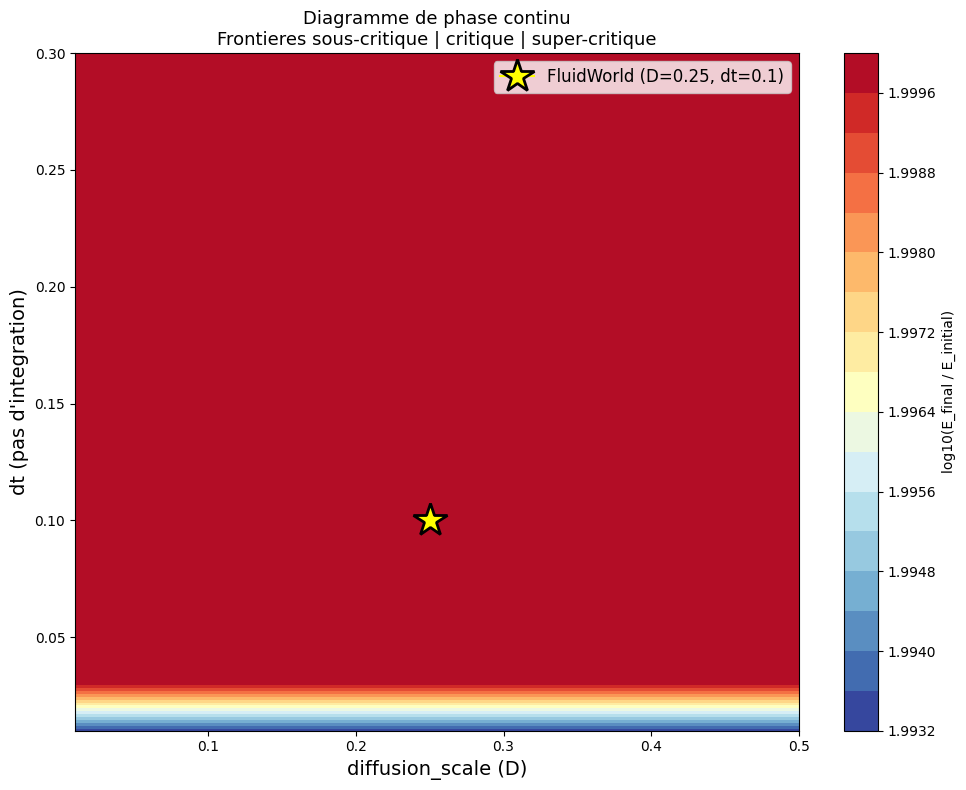

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

# Contour du log du ratio d'energie
D_grid, dt_grid = np.meshgrid(diffusion_scales, dt_values)
log_ratio = np.log10(np.clip(energy_ratio_map, 1e-3, 1e3))

contour = ax.contourf(D_grid, dt_grid, log_ratio, levels=20, cmap='RdYlBu_r')
plt.colorbar(contour, ax=ax, label='log10(E_final / E_initial)')

# Iso-lignes des regimes
ax.contour(D_grid, dt_grid, regime_map, levels=[0.5, 1.5], colors=['cyan', 'orange'],
           linewidths=3, linestyles='--')

# Position du modele
ax.plot(model_D, model_dt, marker='*', color='yellow', markersize=25, 
        markeredgecolor='black', markeredgewidth=2,
        label=f'FluidWorld (D={model_D}, dt={model_dt})')

ax.set_xlabel('diffusion_scale (D)', fontsize=14)
ax.set_ylabel('dt (pas d\'integration)', fontsize=14)
ax.set_title('Diagramme de phase continu\nFrontieres sous-critique | critique | super-critique', fontsize=13)
ax.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

## 7. Per-regime statistics

In [8]:
regime_names = {0: 'Sous-critique', 1: 'Critique', 2: 'Super-critique'}
regime_counts = {}

for regime_id, name in regime_names.items():
    mask = regime_map == regime_id
    count = mask.sum()
    regime_counts[name] = count
    
    if count > 0:
        lyap_vals = lyapunov_map[mask]
        valid_lyap = lyap_vals[~np.isnan(lyap_vals)]
        ratio_vals = energy_ratio_map[mask]
        valid_ratio = ratio_vals[np.isfinite(ratio_vals)]
        
        print(f"\n--- {name} ---")
        print(f"  Nombre de configurations : {count} ({100*count/regime_map.size:.1f}%)")
        if len(valid_lyap) > 0:
            print(f"  Lyapunov moyen : {valid_lyap.mean():.4f} (std={valid_lyap.std():.4f})")
        if len(valid_ratio) > 0:
            print(f"  Ratio E moyen  : {valid_ratio.mean():.4f} (std={valid_ratio.std():.4f})")

# Verifier ou tombe le modele
# Trouver les indices les plus proches
i_model = np.argmin(np.abs(dt_values - model_dt))
j_model = np.argmin(np.abs(diffusion_scales - model_D))
model_regime = regime_names[int(regime_map[i_model, j_model])]
print(f"\n==> Le modele FluidWorld (D={model_D}, dt={model_dt}) est en regime : {model_regime}")


--- Super-critique ---
  Nombre de configurations : 225 (100.0%)
  Lyapunov moyen : 0.0033 (std=0.0039)
  Ratio E moyen  : 99.8979 (std=0.3821)

==> Le modele FluidWorld (D=0.25, dt=0.1) est en regime : Super-critique


## Interpretation

### The edge of chaos

This concept comes from complex systems theory (Langton, 1990). It's the transition zone between:
- **Order** (sub-critical): system converges to a fixed point, loses all information
- **Chaos** (super-critical): system diverges, predictions become impossible

### Why this matters for FluidWorld

A world model needs to:
1. Be expressive: represent diverse states (not sub-critical)
2. Be predictable: small perturbations must not diverge (not super-critical)
3. Be dynamic: the field must evolve in response to stimuli (not a fixed point)

The critical regime satisfies all three.

### Training connection

The PDE-Alive loss (`compute_pde_alive_loss`) penalizes deviations from a target energy. This regularization mechanism pushes the system toward the edge of chaos during training automatically.